# Profitable App Profiles for Apple & Google App Stores

This project aims to identify which mobile app categories are most effective at acquiring users on the Apple App Store and Google Play Store.

Apple data source: https://www.kaggle.com/datasets/ysf12ff/app-store-dataset \
Google data source: https://www.kaggle.com/datasets/muneebullahmuneeb/googleplaystore-dataset

# Importing libraries and data

In [5]:
#!pip install ydata-profiling
# run this if you don't already have ydata-profiling installed.

In [6]:
import os
import kagglehub
import ydata_profiling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [8]:
path1 = kagglehub.dataset_download("ysf12ff/app-store-dataset")
path2 = kagglehub.dataset_download("muneebullahmuneeb/googleplaystore-dataset")

print(path1)
print(path2)

100%|██████████| 289k/289k [00:00<00:00, 66.1MB/s]

Extracting files...


100%|██████████| 312k/312k [00:00<00:00, 61.3MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/ysf12ff/app-store-dataset/versions/2
/root/.cache/kagglehub/datasets/muneebullahmuneeb/googleplaystore-dataset/versions/1


In [9]:
file_list1 = os.listdir(path1)
file_list2 = os.listdir(path2)
print(file_list1)
print(file_list2)

['AppleStore.csv']
['googleplaystore.csv']


In [10]:
apple = pd.read_csv(os.path.join(path1, 'AppleStore.csv'))
google = pd.read_csv(os.path.join(path2, 'googleplaystore.csv'))

In [11]:
display(apple.head())
print('-'*200)
display(google.head())

,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
0,284882215,Facebook,389879808,USD,0.00,2974676,212,3.50,3.50,95,4+,Social Networking,37,1,29,1
1,389801252,Instagram,113954816,USD,0.00,2161558,1289,4.50,4.00,10.23,12+,Photo & Video,37,0,29,1
2,529479190,Clash of Clans,116476928,USD,0.00,2130805,579,4.50,4.50,9.24.12,9+,Games,38,5,18,1
3,420009108,Temple Run,65921024,USD,0.00,1724546,3842,4.50,4.00,1.6.2,9+,Games,40,5,1,1
4,284035177,Pandora - Music & Radio,130242560,USD,0.00,1126879,3594,4.00,4.50,8.4.1,12+,Music,37,4,1,1


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.10,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.90,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.70,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.50,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.30,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


# Data profiling

In [12]:
applerep = ydata_profiling.ProfileReport(apple)
googlerep = ydata_profiling.ProfileReport(google)

In [13]:
#applerep
# uncomment to view profiling report

In [14]:
#googlerep
# uncomment to view profiling report

# Data Cleaning
* The apple store dataset appears quite clean with no duplicates in and missing values.
* The google store dataset has 410 duplicates which have to be removed. It also seems to only contain missing values in the ratings columns, I will fill the missing values with 0.
* Not all values are unique in the app name columns for both stores. I suspect there are duplicate entries with different version numbers.

## Filling missing values

In [15]:
google['Rating'] = google['Rating'].fillna(0)
google.isna().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


## Removing duplicates

In [16]:
apple[apple['track_name'].duplicated()]

,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
4463,1178454060,Mannequin Challenge,59572224,USD,0.00,105,58,4.00,4.50,1.0.1,4+,Games,38,5,1,1
4831,1089824278,VR Roller Coaster,240964608,USD,0.00,67,44,3.50,4.00,0.81,4+,Games,38,0,1,1


In [17]:
apple[(apple['track_name']=='VR Roller Coaster')|(apple['track_name']=='Mannequin Challenge')].sort_values(by='track_name')

,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
2948,1173990889,Mannequin Challenge,109705216,USD,0.00,668,87,3.00,3.00,1.4,9+,Games,37,4,1,1
4463,1178454060,Mannequin Challenge,59572224,USD,0.00,105,58,4.00,4.50,1.0.1,4+,Games,38,5,1,1
4442,952877179,VR Roller Coaster,169523200,USD,0.00,107,102,3.50,3.50,2.0.0,4+,Games,37,5,1,1
4831,1089824278,VR Roller Coaster,240964608,USD,0.00,67,44,3.50,4.00,0.81,4+,Games,38,0,1,1


As I suspected, these apps seem to be duplicates, the version numbers are different, and the total ratings count indicates this as well.

In [18]:
apple = apple.sort_values(by='ver', ascending = False)
apple.drop_duplicates(subset=['track_name'], inplace = True)
apple[apple['track_name'].duplicated()] #This should now return blank

,id,track_name,size_bytes,currency,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,ver,cont_rating,prime_genre,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic


In [19]:
google.drop_duplicates(inplace = True)

In [20]:
google[google['App'].duplicated()]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
285,Quick PDF Scanner + OCR FREE,BUSINESS,4.20,80804,Varies with device,"5,000,000+",Free,0,Everyone,Business,"February 26, 2018",Varies with device,4.0.3 and up
293,OfficeSuite : Free Office + PDF Editor,BUSINESS,4.30,1002859,35M,"100,000,000+",Free,0,Everyone,Business,"August 2, 2018",9.7.14188,4.1 and up
294,Slack,BUSINESS,4.40,51510,Varies with device,"5,000,000+",Free,0,Everyone,Business,"August 2, 2018",Varies with device,Varies with device
382,Messenger – Text and Video Chat for Free,COMMUNICATION,4.00,56646578,Varies with device,"1,000,000,000+",Free,0,Everyone,Communication,"August 1, 2018",Varies with device,Varies with device
383,imo free video calls and chat,COMMUNICATION,4.30,4785988,11M,"500,000,000+",Free,0,Everyone,Communication,"June 8, 2018",9.8.000000010501,4.0 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10647,Motorola FM Radio,VIDEO_PLAYERS,3.90,54815,Varies with device,"100,000,000+",Free,0,Everyone,Video Players & Editors,"May 2, 2018",Varies with device,Varies with device
10715,FarmersOnly Dating,DATING,3.00,1145,1.4M,"100,000+",Free,0,Mature 17+,Dating,"February 25, 2016",2.2,4.0 and up
10720,Firefox Focus: The privacy browser,COMMUNICATION,4.40,36981,4.0M,"1,000,000+",Free,0,Everyone,Communication,"July 6, 2018",5.2,5.0 and up
10730,FP Notebook,MEDICAL,4.50,410,60M,"50,000+",Free,0,Everyone,Medical,"March 24, 2018",2.1.0.372,4.4 and up


In [21]:
google[google['App']=='Quick PDF Scanner + OCR FREE']

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
222,Quick PDF Scanner + OCR FREE,BUSINESS,4.20,80805,Varies with device,"5,000,000+",Free,0,Everyone,Business,"February 26, 2018",Varies with device,4.0.3 and up
285,Quick PDF Scanner + OCR FREE,BUSINESS,4.20,80804,Varies with device,"5,000,000+",Free,0,Everyone,Business,"February 26, 2018",Varies with device,4.0.3 and up


Likewise for google, I will sort the data on 'last updated' and keep only the latest version

In [22]:
google.sort_values(by='Last Updated', ascending = False)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
6834,Kim Bu Youtuber?,FAMILY,0.00,11,9.2M,"1,000+",Free,0,Everyone,Puzzle,"September 9, 2017",1.0,4.0 and up
9437,EI国际,FAMILY,4.70,15,5.2M,"1,000+",Free,0,Everyone,Education,"September 9, 2016",1.0.4,4.0 and up
10393,SnowMobile Parking Adventure,GAME,3.60,12257,49M,"1,000,000+",Free,0,Everyone,Racing,"September 9, 2016",1.4,2.3 and up
6983,Best Friends Dress Up & Makeup,FAMILY,3.70,7664,44M,"500,000+",Free,0,Everyone,Casual;Pretend Play,"September 9, 2015",1.0.3,4.0.3 and up
2952,Add Text To Photo,PHOTOGRAPHY,4.10,21578,1.6M,"1,000,000+",Free,0,Everyone,Photography,"September 8, 2017",1.1.3,2.3 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8901,DU Browser—Browse fast & fun,COMMUNICATION,4.30,1133539,4.7M,"10,000,000+",Free,0,Everyone,Communication,"April 1, 2016",6.4.0.4,4.0 and up
3304,Graphing Calculator,TOOLS,3.90,12388,5.3M,"1,000,000+",Free,0,Everyone,Tools,"April 1, 2016",1.17,2.3 and up
424,DU Browser—Browse fast & fun,COMMUNICATION,4.30,1133501,4.7M,"10,000,000+",Free,0,Everyone,Communication,"April 1, 2016",6.4.0.4,4.0 and up
9116,PHARMAGUIDE (DZ),HEALTH_AND_FITNESS,4.10,131,3.4M,"5,000+",Free,0,Everyone,Health & Fitness,"April 1, 2016",1.06,1.6 and up


It seems that the date column is in a string format, we'll have to change it to date format in order to sort it. I also noticed the last row (Life Made WI-Fi Touchscreen Photo Frame) seems to be an error entry, I will remove this row from the dataframe.

In [23]:
google.drop(10472, inplace = True)
google['Last Updated']= pd.to_datetime(google['Last Updated'])
google.sort_values(by='Last Updated', ascending = False)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10408,Shoot Hunter-Gun Killer,GAME,4.30,320334,27M,"50,000,000+",Free,0,Teen,Action,2018-08-08,1.1.2,4.1 and up
10712,Lalafo Pulsuz Elanlar,SHOPPING,4.40,61392,Varies with device,"1,000,000+",Free,0,Everyone,Shopping,2018-08-08,Varies with device,Varies with device
10718,BankNordik,FINANCE,3.90,28,15M,"5,000+",Free,0,Everyone,Finance,2018-08-08,7.3.2,5.0 and up
10760,Fast Tract Diet,HEALTH_AND_FITNESS,4.40,35,2.4M,"1,000+",Paid,$7.99,Everyone,Health & Fitness,2018-08-08,1.9.3,4.2 and up
10209,Video Downloader For FB: Save FB Videos 2018,TOOLS,4.30,434,3.6M,"50,000+",Free,0,Everyone,Tools,2018-08-08,1.1.9,4.0.3 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8084,Freecell CY,GAME,4.00,387,1.1M,"50,000+",Free,0,Everyone,Card,2011-04-16,1.3.3,1.6 and up
8418,DEER HUNTER CHALLENGE,GAME,3.70,38767,4.1M,"5,000,000+",Free,0,Everyone 10+,Action,2011-04-11,1.4.3,2.0 and up
10282,FD Shift Calendar Widget,TOOLS,4.10,981,73k,"100,000+",Free,0,Everyone,Tools,2011-03-16,1.2.4,1.6 and up
7430,CJ Poker Odds Calculator,GAME,4.10,207,116k,"50,000+",Free,0,Everyone,Card,2011-01-30,1.2,1.6 and up


In [24]:
google = google.sort_values(by='Last Updated', ascending = False)
google = google.drop_duplicates(subset=['App'])
google[google['App'].duplicated()] #This should now return blank

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


## Changing data types
The data types for reviews and price in the google dataset are strings. This will have be converted to numeric Dtypes for aggregation tasks.

In [25]:
google['Price']=google['Price'].str.strip('$')
google['Price']=google['Price'].apply(pd.to_numeric)
google['Reviews']=google['Reviews'].apply(pd.to_numeric)

## Outliers

In [26]:
apple.describe()

,id,size_bytes,price,rating_count_tot,rating_count_ver,user_rating,user_rating_ver,sup_devices.num,ipadSc_urls.num,lang.num,vpp_lic
count,7195.00,7195.00,7195.00,7195.00,7195.00,7195.00,7195.00,7195.00,7195.00,7195.00,7195.00
mean,863055665.09,199148037.16,1.73,12896.47,460.49,3.53,3.25,37.36,3.71,5.44,0.99
std,271235802.53,359252734.57,5.83,75749.64,3920.99,1.52,1.81,3.74,1.99,7.92,0.08
min,281656475.00,589824.00,0.00,0.00,0.00,0.00,0.00,9.00,0.00,0.00,0.00
25%,600093611.50,46901760.00,0.00,28.00,1.00,3.50,2.50,37.00,3.00,1.00,1.00
50%,977965019.00,97153024.00,0.00,300.00,23.00,4.00,4.00,37.00,5.00,1.00,1.00
75%,1082267097.50,181851648.00,1.99,2793.00,140.00,4.50,4.50,38.00,5.00,8.00,1.00
max,1188375727.00,4025969664.00,299.99,2974676.00,177050.00,5.00,5.00,47.00,5.00,75.00,1.00


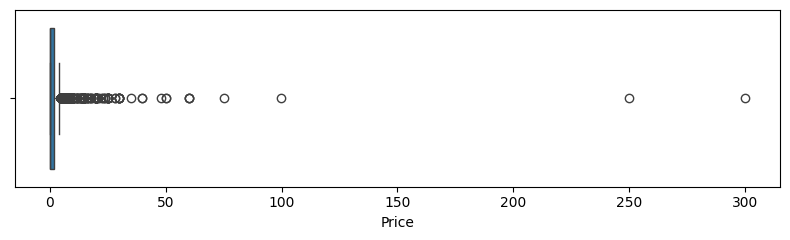

In [27]:
plt.figure(figsize=(8, 2.5))
sns.boxplot(x=apple['price'], whis=1.5, showfliers=True)
plt.xlabel('Price')
plt.tight_layout()
plt.show()

In [28]:
google.describe()

,Rating,Reviews,Price,Last Updated
count,9659.00,9659.00,9659.00,9659
mean,3.54,216733.59,1.10,2017-10-31 02:10:53.732270336
min,0.00,0.00,0.00,2010-05-21 00:00:00
25%,3.60,25.00,0.00,2017-08-07 00:00:00
50%,4.20,969.00,0.00,2018-05-05 00:00:00
75%,4.50,29440.50,0.00,2018-07-17 00:00:00
max,5.00,78158306.00,400.00,2018-08-08 00:00:00
std,1.58,1831269.03,16.85,NaN


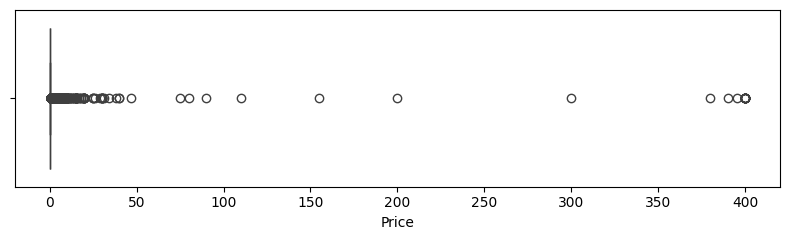

In [29]:
plt.figure(figsize=(8, 2.5))
sns.boxplot(x=google['Price'], whis=1.5, showfliers=True)
plt.xlabel('Price')
plt.tight_layout()
plt.show()

It seems most apps are priced at $50 and below, we'll use that as the limit.

In [30]:
apple = apple[apple['price'] <= 50]
google = google[google['Price'] <= 50]

Apps like facebook / instagram have way above average number of users, influencing the average user numbers within each genre.\
These should also be filtered. We'll set the limit at the 90% quantile.

In [31]:
apple=apple[apple['rating_count_tot']<=apple['rating_count_tot'].quantile(0.9)]
google=google[google['Reviews']<=google['Reviews'].quantile(0.9)]

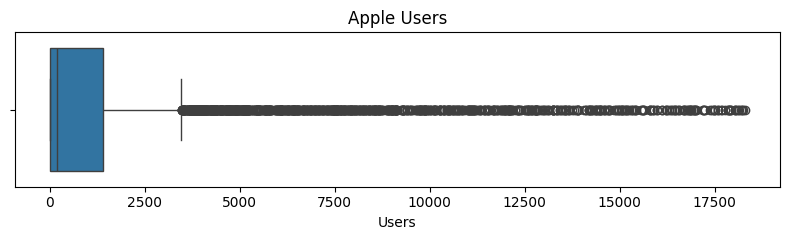

In [32]:
plt.figure(figsize=(8, 2.5))
ax = sns.boxplot(x=apple['rating_count_tot'])
ax.ticklabel_format(style='plain', axis='x', useOffset=False)
plt.xlabel('Users')
plt.title('Apple Users')
plt.tight_layout()
plt.show()

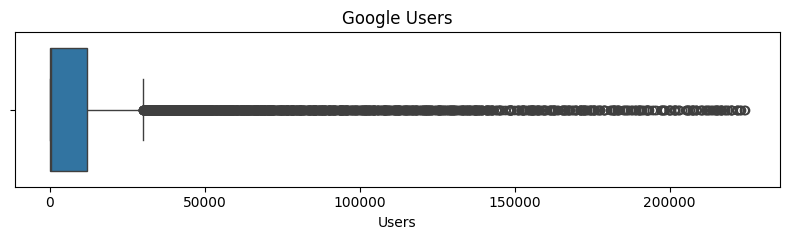

In [33]:
plt.figure(figsize=(8, 2.5))
ax = sns.boxplot(x=google['Reviews'])
ax.ticklabel_format(style='plain', axis='x', useOffset=False)
plt.xlabel('Users')
plt.title('Google Users')
plt.tight_layout()
plt.show()

## Tidying up text column

In [34]:
google['Category'].unique()

array(['SHOPPING', 'FINANCE', 'HEALTH_AND_FITNESS', 'TOOLS',
       'AUTO_AND_VEHICLES', 'SOCIAL', 'SPORTS', 'COMMUNICATION',
       'BUSINESS', 'NEWS_AND_MAGAZINES', 'FAMILY', 'GAME', 'LIFESTYLE',
       'WEATHER', 'PERSONALIZATION', 'PARENTING', 'VIDEO_PLAYERS',
       'MAPS_AND_NAVIGATION', 'PHOTOGRAPHY', 'TRAVEL_AND_LOCAL',
       'BOOKS_AND_REFERENCE', 'PRODUCTIVITY', 'MEDICAL', 'BEAUTY',
       'FOOD_AND_DRINK', 'HOUSE_AND_HOME', 'DATING', 'EVENTS',
       'ENTERTAINMENT', 'ART_AND_DESIGN', 'EDUCATION', 'COMICS',
       'LIBRARIES_AND_DEMO'], dtype=object)

In [35]:
google['Category'] = (google['Category']
      .str.replace('_AND_', ' & ', regex=False)
      .str.replace('_', ' ', regex=False)
      .str.title())
google['Category'].unique()

array(['Shopping', 'Finance', 'Health & Fitness', 'Tools',
       'Auto & Vehicles', 'Social', 'Sports', 'Communication', 'Business',
       'News & Magazines', 'Family', 'Game', 'Lifestyle', 'Weather',
       'Personalization', 'Parenting', 'Video Players',
       'Maps & Navigation', 'Photography', 'Travel & Local',
       'Books & Reference', 'Productivity', 'Medical', 'Beauty',
       'Food & Drink', 'House & Home', 'Dating', 'Events',
       'Entertainment', 'Art & Design', 'Education', 'Comics',
       'Libraries & Demo'], dtype=object)

## Filtering

we can now remove the redundant columns that do not provide any meaningful analysis such as id, size, OS version, etc.
Genres in the google dataset seems to be a subcategory, this should also be removed

In [36]:
apple.info()
google.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6469 entries, 5306 to 4610
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                6469 non-null   int64  
 1   track_name        6469 non-null   object 
 2   size_bytes        6469 non-null   int64  
 3   currency          6469 non-null   object 
 4   price             6469 non-null   float64
 5   rating_count_tot  6469 non-null   int64  
 6   rating_count_ver  6469 non-null   int64  
 7   user_rating       6469 non-null   float64
 8   user_rating_ver   6469 non-null   float64
 9   ver               6469 non-null   object 
 10  cont_rating       6469 non-null   object 
 11  prime_genre       6469 non-null   object 
 12  sup_devices.num   6469 non-null   int64  
 13  ipadSc_urls.num   6469 non-null   int64  
 14  lang.num          6469 non-null   int64  
 15  vpp_lic           6469 non-null   int64  
dtypes: float64(3), int64(8), object(5)
memory us

In [37]:
apple=apple.drop(apple.columns[[0,2,3,6,8,9,12,13,14,15]],axis =1)
google=google.drop(google.columns[[4,5,6,9,10,11,12]],axis =1)

apple.info()
google.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6469 entries, 5306 to 4610
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_name        6469 non-null   object 
 1   price             6469 non-null   float64
 2   rating_count_tot  6469 non-null   int64  
 3   user_rating       6469 non-null   float64
 4   cont_rating       6469 non-null   object 
 5   prime_genre       6469 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 353.8+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 8672 entries, 10712 to 7479
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             8672 non-null   object 
 1   Category        8672 non-null   object 
 2   Rating          8672 non-null   float64
 3   Reviews         8672 non-null   int64  
 4   Price           8672 non-null   float64
 5   Content Rating  8672 non-null  

## Standardising data

In [38]:
apple.rename(columns = {'track_name':'App','price':'Price','rating_count_tot':'Reviews',
                        'user_rating':'Rating','cont_rating':'Content Rating',
                        'prime_genre':'Category'}, inplace = True)
apple = apple[['App','Category','Rating','Reviews','Price','Content Rating']]

# EDA

## Correlations

<Axes: >

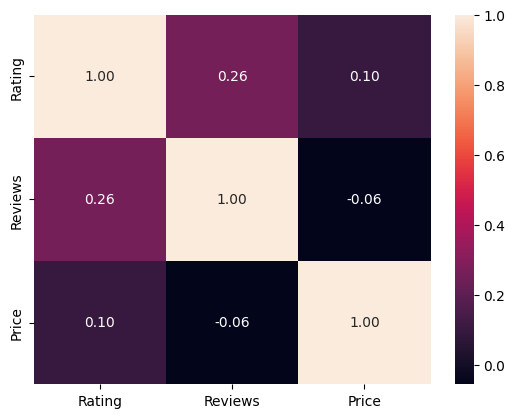

In [39]:
sns.heatmap(apple.corr(numeric_only=True),fmt ='.2f', annot=True)

<Axes: >

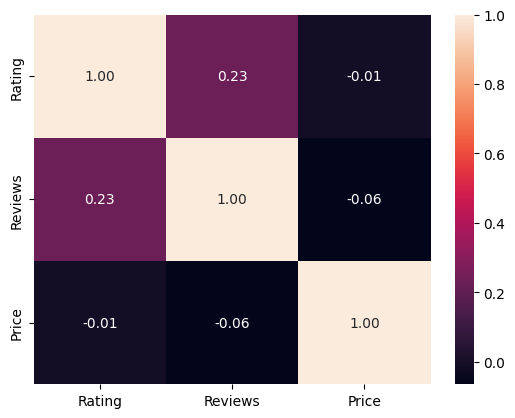

In [40]:
sns.heatmap(google.corr(numeric_only=True),fmt ='.2f', annot=True)

Though weak, number of reviews seem to be correlated to ratings

## Market share of each genre

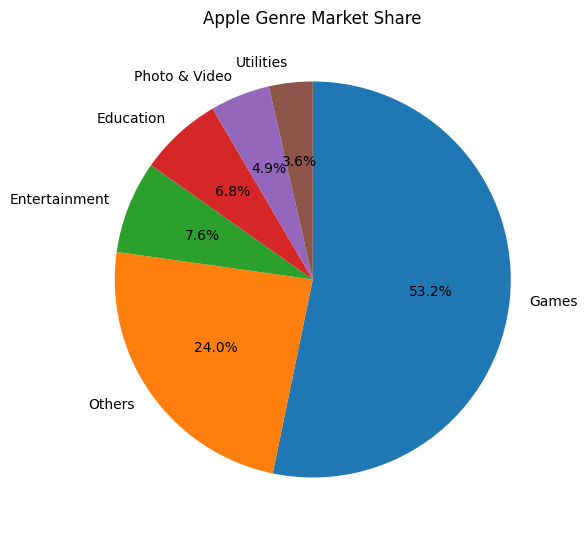

In [41]:
group = (apple.groupby('Category')['Category'].count() / len(apple) * 100).round(2)
group = group.sort_values(ascending=False)

top_labels = group.index[:5]
topgenres = group[top_labels]
othergenres = group[~group.index.isin(top_labels)].sum()

all = pd.concat([topgenres, pd.Series({'Others': othergenres})]).sort_values(ascending=False)

plt.figure(figsize=(6, 6))
plt.pie(
    x=all.values,
    labels=all.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
)
plt.title('Apple Genre Market Share')
plt.tight_layout()
plt.show()

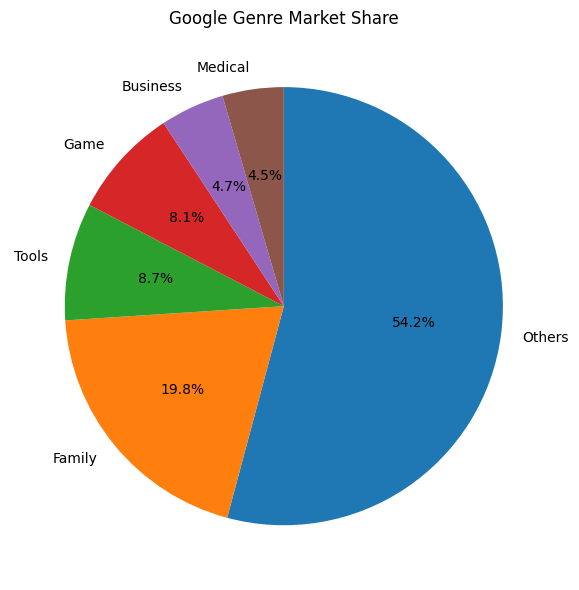

In [42]:
group = (google.groupby('Category')['Category'].count() / len(google) * 100).round(2)
group = group.sort_values(ascending=False)

top_labels = group.index[:5]
topgenres = group[top_labels]
othergenres = group[~group.index.isin(top_labels)].sum()

all = pd.concat([topgenres, pd.Series({'Others': othergenres})]).sort_values(ascending=False)

plt.figure(figsize=(6, 6))
plt.pie(
    x=all.values,
    labels=all.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
)
plt.title('Google Genre Market Share')
plt.tight_layout()
plt.show()

Games take up more than half the market share in the apple app store, while the family genre takes up about 1/5th of the market share on the google store. 'Others' take up more than half of the market share, let's investigate further.

In [43]:
print(np.sort(apple['Category'].unique()))
print('-'*100)
print(np.sort(google['Category'].unique()))

['Book' 'Business' 'Catalogs' 'Education' 'Entertainment' 'Finance'
 'Food & Drink' 'Games' 'Health & Fitness' 'Lifestyle' 'Medical' 'Music'
 'Navigation' 'News' 'Photo & Video' 'Productivity' 'Reference' 'Shopping'
 'Social Networking' 'Sports' 'Travel' 'Utilities' 'Weather']
----------------------------------------------------------------------------------------------------
['Art & Design' 'Auto & Vehicles' 'Beauty' 'Books & Reference' 'Business'
 'Comics' 'Communication' 'Dating' 'Education' 'Entertainment' 'Events'
 'Family' 'Finance' 'Food & Drink' 'Game' 'Health & Fitness'
 'House & Home' 'Libraries & Demo' 'Lifestyle' 'Maps & Navigation'
 'Medical' 'News & Magazines' 'Parenting' 'Personalization' 'Photography'
 'Productivity' 'Shopping' 'Social' 'Sports' 'Tools' 'Travel & Local'
 'Video Players' 'Weather']


In [44]:
print(apple['Category'].nunique())
print(google['Category'].nunique())

23
33


Google's store has 10 more categories than apple's, let's see if we can group some of these categories together.

In [45]:
google[google['Category']=='Family'].head(10)

,App,Category,Rating,Reviews,Price,Content Rating
9780,Scanner Radio - Fire and Police Scanner,Family,4.40,175509,0.00,Everyone
10435,Bubble Bird Rescue,Family,4.20,70753,0.00,Everyone
9677,Masha and The Bear Jam Day Match 3 games for kids,Family,4.60,50060,0.00,Everyone
9089,DYPSOET,Family,5.00,8,0.00,Everyone
9846,Beauty and the Beast,Family,4.40,70883,0.00,Everyone
9746,Plastic Surgery Surgeon Simulator Er Doctor Games,Family,3.70,3482,0.00,Everyone
10502,Fun Kid Racing - Motocross,Family,4.10,59768,0.00,Everyone
9736,Lifeguard Beach Rescue ER Emergency Hospital G...,Family,3.90,519,0.00,Everyone
8010,"Freeform – Stream Full Episodes, Movies, & Liv...",Family,3.70,29229,0.00,Teen
2081,Fuzzy Seasons: Animal Forest,Family,4.80,12137,0.00,Everyone 10+


It seems games for kids are classified as 'Family' in the google store.

In [46]:
games = google['App'].str.contains(r'\bgames?\b', case=False, na=False)
google.loc[games, 'Category'] = 'Game'

In [47]:
google[google['Category']=='Parenting'].head(10)

,App,Category,Rating,Reviews,Price,Content Rating
3590,Baby Food - Homemade Recipes,Parenting,4.10,44,0.00,Everyone
3601,Baby Name Together,Parenting,4.00,464,0.00,Everyone
3599,Educational Children's Songs,Parenting,0.00,163,0.00,Everyone
3610,Johny Johny Yes Papa Nursery Rhyme - offline V...,Parenting,4.50,806,0.00,Everyone
3575,Baby Names,Parenting,4.50,86,0.00,Everyone
3598,Family GPS Tracker and Chat + Baby Monitor Online,Parenting,4.40,9073,0.00,Everyone
3613,Urban Limo Taxi Simulator,Parenting,3.80,824,0.00,Everyone
3625,Feed Baby - Baby Tracker,Parenting,4.50,76795,0.00,Everyone
3597,Family Album Mitene: Private Photo & Video Sha...,Parenting,4.70,34336,0.00,Everyone
7631,AppClose - The #1 FREE Co-Parenting App,Parenting,3.50,159,0.00,Everyone


I think the 'Parenting' category can be grouped with 'Family'.

In [48]:
parenting = google['Category']=='Parenting'
google.loc[parenting, 'Category'] = 'Family'

In [49]:
google[google['Category']=='Personalization'].head(10)

,App,Category,Rating,Reviews,Price,Content Rating
10710,Stylish Fonts,Personalization,3.80,153176,0.00,Everyone
3355,"XOS - Launcher,Theme,Wallpaper",Personalization,4.60,49657,0.00,Everyone
4577,PitchBlack S - Samsung Substratum Theme “For O...,Personalization,4.50,90,1.99,Everyone
4834,Space Z 🌏 🚀Icon Pack Theme,Personalization,4.80,201,1.49,Everyone
3362,OnePlus Launcher,Personalization,4.00,24215,0.00,Everyone
3357,Evie Launcher,Personalization,4.70,139258,0.00,Everyone
4438,OO Launcher for Android O 8.0 Oreo™ Launcher,Personalization,4.40,14832,0.00,Everyone
4483,Materialistic P Wallpapers,Personalization,4.80,24,0.00,Everyone
4403,Dark Infusion Substratum Theme for Android N & O,Personalization,4.80,133,2.49,Everyone
8686,DP & Status for Whatsapp 2018,Personalization,4.10,293,0.00,Everyone


In [50]:
google[google['Category']=='Tools'].head(10)

,App,Category,Rating,Reviews,Price,Content Rating
10209,Video Downloader For FB: Save FB Videos 2018,Tools,4.30,434,0.00,Everyone
9207,Bihar Land Records - RoR and EB Quick Pay,Tools,4.00,8,0.00,Everyone
9213,Punjab Online - Land Records • EB Bill Pay • R...,Tools,3.40,16,0.00,Everyone
10473,osmino Wi-Fi: free WiFi,Tools,4.20,134203,0.00,Everyone
3236,Moto Display,Tools,4.20,18239,0.00,Everyone
3292,Flashlight,Tools,4.70,115409,0.00,Everyone
9226,TN Patta Chitta EC Info,Tools,4.20,1611,0.00,Everyone
3262,Clear,Tools,3.10,24151,0.00,Everyone
8131,CZ File Manager,Tools,2.20,876,0.00,Everyone
7562,CM AppLock Fingerprint 2018,Tools,4.40,1264,0.00,Everyone


'Personalization' and 'Tools' seem to be utility apps.

In [51]:
utility = (google['Category'].eq('Personalization')) | (google['Category'].eq('Tools'))
google.loc[utility, 'Category'] = 'Utilities'

In [52]:
google[google['Category']=='Beauty'].head(10)

,App,Category,Rating,Reviews,Price,Content Rating
10289,Female Daily,Beauty,3.90,4354,0.00,Teen
98,Hush - Beauty for Everyone,Beauty,4.70,18900,0.00,Everyone
136,Rainbow Camera,Beauty,3.70,3871,0.00,Everyone
111,Colors of white in Urdu,Beauty,4.50,36,0.00,Everyone
104,Hairstyles step by step,Beauty,4.60,4369,0.00,Everyone
112,Selfie Camera Photo Editor & Filter & Sticker,Beauty,4.10,187,0.00,Teen
122,"Sephora: Skin Care, Beauty Makeup & Fragrance ...",Beauty,4.50,26834,0.00,Everyone
123,Manicure - nail design,Beauty,0.00,119,0.00,Everyone
7021,Best Hairstyles step by step,Beauty,4.50,45452,0.00,Everyone
126,Skin Care and Natural Beauty,Beauty,0.00,654,0.00,Teen


'Beauty' apps can be grouped with 'Lifestyle'

In [53]:
beauty = google['Category']=='Beauty'
google.loc[beauty, 'Category'] = 'Lifestyle'

In [54]:
google[google['Category']=='Dating'].head(10)

,App,Category,Rating,Reviews,Price,Content Rating
555,Heart mill,Dating,3.30,4631,0.00,Mature 17+
493,Free Dating App & Flirt Chat - Match with Singles,Dating,4.40,172460,0.00,Mature 17+
656,Titanic App - Feminist Dating Application,Dating,4.50,120,0.00,Mature 17+
691,SkyLove – Dating and chat,Dating,3.50,69,0.00,Mature 17+
486,Hinge: Dating & Relationships,Dating,4.20,7779,0.00,Mature 17+
648,Iraq love chat,Dating,0.00,14,0.00,Teen
497,Mingle2 - Free Online Dating & Singles Chat Rooms,Dating,4.30,37053,0.00,Mature 17+
498,Free Dating App & Flirt Chat - Cheers,Dating,4.40,667,0.00,Mature 17+
581,JustDating,Dating,4.00,13440,0.00,Mature 17+
540,"USA Singles Meet, Match and Date Free - Date",Dating,4.20,5084,0.00,Mature 17+


Likewise for dating apps

In [55]:
dating = google['Category']=='Dating'
google.loc[dating, 'Category'] = 'Lifestyle'

In [56]:
google[google['Category']=='Comics'].head(10)

,App,Category,Rating,Reviews,Price,Content Rating
6424,Manga Books,Comics,3.80,7326,0.00,Adults only 18+
301,Unicorn Pokez - Color By Number,Comics,4.80,516,0.00,Everyone
332,think Comics,Comics,4.40,1006,0.00,Everyone
334,"Laftel - Watching and Announcing Snooping, Str...",Comics,4.60,4895,0.00,Everyone
302,MangaToon - Comics updated Daily,Comics,3.90,834,0.00,Mature 17+
330,Perfect Viewer,Comics,4.40,51981,0.00,Everyone
8260,"Superheroes, Marvel, DC, Comics, TV, Movies News",Comics,5.00,34,0.00,Everyone
6408,Lezhin Comics - Daily Releases,Comics,3.00,28447,0.00,Teen
318,"Tapas – Comics, Novels, and Stories",Comics,4.50,29839,0.00,Teen
327,pixiv comic - everyone's manga app,Comics,4.40,18814,0.00,Mature 17+


I think 'Comics' can be grouped with 'Entertainment'

In [57]:
comics = google['Category']=='Comics'
google.loc[comics, 'Category'] = 'Entertainment'

In [58]:
google[google['Category']=='Medical'].head(10)

,App,Category,Rating,Reviews,Price,Content Rating
2331,mySugr: the blood sugar tracker made just for you,Medical,4.60,21189,0.00,Everyone
9055,Human Dx,Medical,4.80,6,0.00,Everyone
9745,Doctr – ER wait times in Canada,Medical,4.20,980,0.00,Everyone
2423,ABG Master,Medical,0.00,2,0.99,Everyone
2441,PCOS Guide - Fight PCOS naturally,Medical,0.00,0,0.00,Everyone
2476,Interpret Chest X-Ray With 100 Cases,Medical,4.60,5,0.00,Everyone
2450,Tablet Reminder,Medical,5.00,4,0.00,Everyone
2445,Labs on Demand,Medical,5.00,1,0.00,Everyone
2307,Ovia Pregnancy Tracker & Baby Countdown Calendar,Medical,4.80,102858,0.00,Everyone
2319,My Calendar - Period Tracker,Medical,4.70,156410,0.00,Everyone


'Medical' can be grouped with 'Health & Fitness'

In [59]:
medical = google['Category']=='Medical'
google.loc[medical, 'Category'] = 'Health & Fitness'

In [60]:
google[google['Category']=='Video Players'].head(10)

,App,Category,Rating,Reviews,Price,Content Rating
3679,OBJECTIVE,Video Players,3.80,19738,0.00,Teen
3682,"YouCut - Video Editor & Video Maker, No Watermark",Video Players,4.60,98819,0.00,Everyone
8814,DS video,Video Players,3.80,12443,0.00,Everyone
3699,Video.Guru - Video Maker,Video Players,4.60,36969,0.00,Everyone
3714,VUE: video editor & camcorder,Video Players,4.40,38630,0.00,Everyone
4682,All Video Downloader,Video Players,3.80,165723,0.00,Everyone
7064,BZ Langenthaler Tagblatt,Video Players,0.00,22,0.00,Everyone
3677,Vote for,Video Players,4.20,193381,0.00,Teen
3683,"Video Editor,Crop Video,Movie Video,Music,Effects",Video Players,4.70,53006,0.00,Everyone
3667,Video Downloader,Video Players,4.20,59089,0.00,Everyone


I think these can be classified as 'Utilities' as well.

In [61]:
vid = google['Category']=='Video Players'
google.loc[vid, 'Category'] = 'Utilities'

In [62]:
print(google['Category'].nunique())

26


We've managed to reduce the groups from 33 to 26 categories. Let's check the chart again.

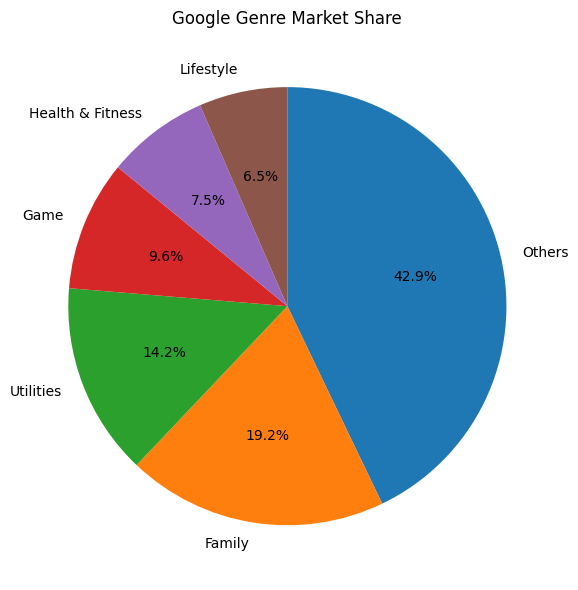

In [63]:
group = (google.groupby('Category')['Category'].count() / len(google) * 100).round(2)
group = group.sort_values(ascending=False)

top_labels = group.index[:5]
topgenres = group[top_labels]
othergenres = group[~group.index.isin(top_labels)].sum()

all = pd.concat([topgenres, pd.Series({'Others': othergenres})]).sort_values(ascending=False)

plt.figure(figsize=(6, 6))
plt.pie(
    x=all.values,
    labels=all.index,
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False
)
plt.title('Google Genre Market Share')
plt.tight_layout()
plt.show()

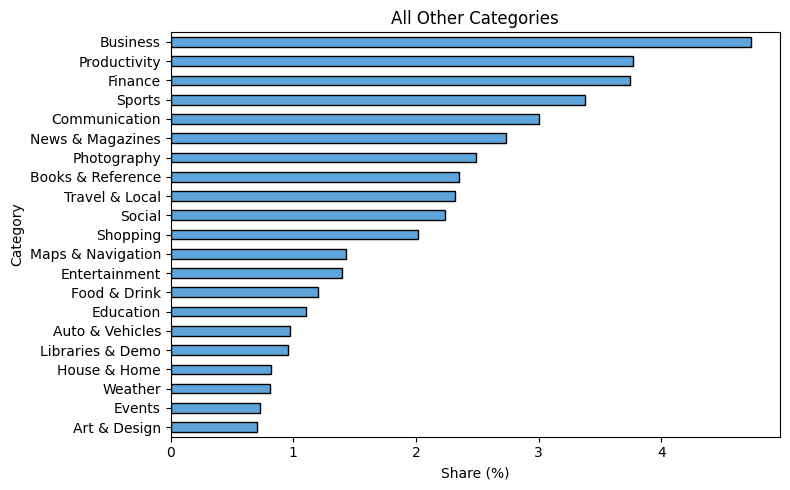

In [64]:
allothers = group[~group.index.isin(top_labels)].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
ordered = allothers.sort_values()
ordered.plot(kind='barh', color='#5DA5DA', edgecolor='black')
plt.xlabel('Share (%)')
plt.ylabel('Category')
plt.title("All Other Categories")
plt.tight_layout()
plt.show()

It seems family and ulitites hold the biggest market share on the google app store.

## Averages number of users across genres
We'll use the number of reviews as the number of total users.

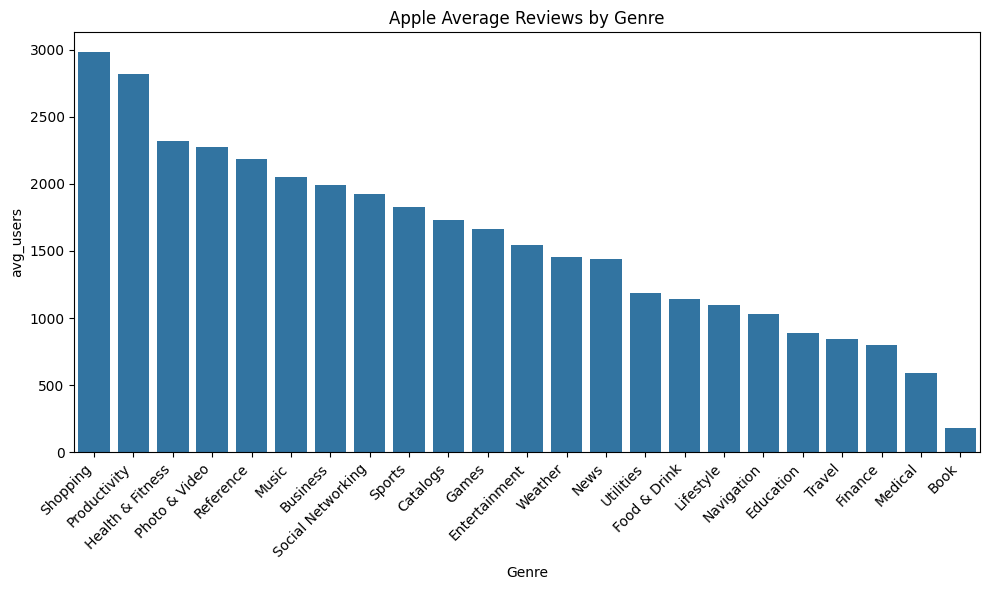

In [65]:
group = apple.groupby('Category')['Reviews'].mean().sort_values(ascending=False)
group = group.reset_index(name='avg_users')

plt.figure(figsize=(10, 6))
sns.barplot(
    data=group,
    x='Category', y='avg_users',
    order=group['Category'],
    errorbar=None
)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Genre')
plt.ylabel('avg_users')
plt.title('Apple Average Reviews by Genre')
plt.tight_layout()
plt.show()

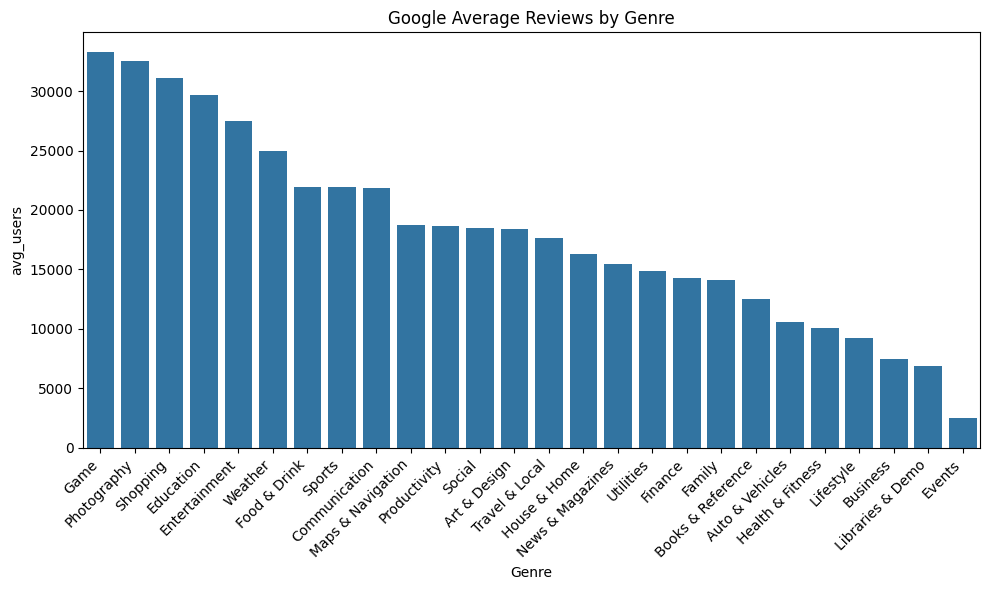

In [66]:
group = google.groupby('Category')['Reviews'].mean().sort_values(ascending=False)
group = group.reset_index(name='avg_users')

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=group,
    x='Category', y='avg_users',
    order=group['Category'],
    errorbar=None)

ax.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Genre')
plt.ylabel('avg_users')
plt.title('Google Average Reviews by Genre')
plt.tight_layout()
plt.show()

Shopping apps have the most number of average users on apple's store, while games have the most number of average users on google's.

##Top 5 average most used genres

In [67]:
applemostpop = apple.groupby('Category')['Reviews'].mean().sort_values(ascending=False).head()
googlemostpop = google.groupby('Category')['Reviews'].mean().sort_values(ascending=False).head()

In [68]:
print(applemostpop)
print('-'*50)
print(googlemostpop)

Category
Shopping           2978.96
Productivity       2816.14
Health & Fitness   2318.16
Photo & Video      2274.41
Reference          2187.03
Name: Reviews, dtype: float64
--------------------------------------------------
Category
Game            33270.52
Photography     32482.59
Shopping        31130.50
Education       29660.11
Entertainment   27457.64
Name: Reviews, dtype: float64


Shopping and photography apps are amongst the most used categories in both app stores.

In [69]:
popularinboth = ['Shopping','Photo & Video','Photography']

In [70]:
for cat in applemostpop.index:
    if cat in popularinboth:
      print(f"\nTop apps in {cat} category:")
      top_apps = apple[apple['Category'] == cat]\
                 .sort_values(by='Reviews', ascending=False)\
                 .head(10)
      display(top_apps)


Top apps in Shopping category:


,App,Category,Rating,Reviews,Price,Content Rating
727,Poshmark: Buy & Sell Fashion,Shopping,4.50,18035,0.00,4+
729,Whole Foods Market,Shopping,3.00,17906,0.00,4+
778,5miles: Buy and Sell Used Stuff Locally,Shopping,4.50,16105,0.00,4+
790,Sephora Makeup & Beauty App – Insider Tips & S...,Shopping,4.50,15593,0.00,4+
817,Cartwheel by Target,Shopping,3.50,14682,0.00,4+
891,SHEIN Shopping - Women's Clothing & Fashion,Shopping,4.50,12663,0.00,12+
892,"Ebates: Cash Back, Coupons & Rebate Shopping App",Shopping,5.00,12617,0.00,4+
895,"Wayfair - Shop Furniture, Home Decor, Daily Sales",Shopping,5.00,12578,0.00,4+
900,CVS,Shopping,4.50,12402,0.00,17+
906,SNKRS,Shopping,4.50,12298,0.00,4+



Top apps in Photo & Video category:


,App,Category,Rating,Reviews,Price,Content Rating
761,"Camera360 - Selfie Filter Camera, Photo Editor",Photo & Video,4.50,16729,0.00,12+
776,"Over— Edit Photos, Add Text & Captions to Pict...",Photo & Video,4.50,16221,0.00,4+
775,InstaMag - Free Pic and Photo Collage Maker,Photo & Video,4.50,16221,0.00,4+
787,Photo Transfer App - Easy backup of photos+videos,Photo & Video,4.50,15654,0.00,4+
789,"InstaSize: Photo Editor, Picture Effects & Col...",Photo & Video,4.00,15605,0.00,4+
804,"Prisma: Photo Editor, Art Filters Pic Effects",Photo & Video,4.50,15060,0.00,9+
814,"Filterra – Photo Editor, Effects for Pictures",Photo & Video,4.50,14744,0.00,4+
839,YouCam Makeup: Magic Makeup Selfie Cam,Photo & Video,4.50,14188,0.00,9+
842,Afterlight,Photo & Video,4.50,14057,0.99,4+
875,MSQRD — Live Filters & Face Swap for Video Sel...,Photo & Video,4.50,12982,0.00,9+


In [71]:
for cat in googlemostpop.index:
    if cat in popularinboth:
      print(f"\nTop apps in {cat} category:")
      top_apps = google[google['Category'] == cat]\
                 .sort_values(by='Reviews', ascending=False)\
                 .head(10)
      display(top_apps)


Top apps in Photography category:


,App,Category,Rating,Reviews,Price,Content Rating
9862,A+ Gallery - Photos & Videos,Photography,4.50,223941,0.00,Everyone
8126,Camera360 Lite - Selfie Camera,Photography,4.40,221878,0.00,Everyone
2809,Motorola Camera,Photography,3.60,219745,0.00,Everyone
2907,EyeEm - Camera & Photo Filter,Photography,4.20,215343,0.00,Everyone
2951,Font Studio- Photo Texts Image,Photography,4.20,197295,0.00,Everyone
6051,Photo Editor by BeFunky,Photography,4.50,192851,0.00,Everyone
4443,Pixlr-o-matic,Photography,4.50,180697,0.00,Everyone
2940,Color Touch Effects,Photography,3.80,167652,0.00,Everyone
5037,AfterFocus,Photography,4.20,165224,0.00,Everyone
10716,Free Slideshow Maker & Video Editor,Photography,4.20,162564,0.00,Everyone



Top apps in Shopping category:


,App,Category,Rating,Reviews,Price,Content Rating
2678,bigbasket - online grocery,Shopping,4.30,216741,0.00,Everyone
2711,"Shopkick: Free Gift Cards, Shop Rewards & Deals",Shopping,4.30,213735,0.00,Everyone
2715,"RetailMeNot - Coupons, Deals & Discount Shopping",Shopping,4.40,210208,0.00,Everyone
2753,Best Buy,Shopping,4.40,186116,0.00,Everyone
2710,The Coupons App,Shopping,4.50,181990,0.00,Everyone
2800,ASOS,Shopping,4.70,181823,0.00,Everyone
2696,Wemep - Special price representative (special ...,Shopping,4.50,178497,0.00,Everyone
2686,Blibli.com Online Shopping,Shopping,4.20,171584,0.00,Everyone
2683,Jumia online shopping,Shopping,4.30,162655,0.00,Teen
7520,Postings (Craigslist Search App),Shopping,4.30,151095,0.00,Mature 17+


# Conclusion

## Findings
* Photography and Shopping both appear among the highest-average-use genres across Apple and Google devices.

* The top-performing apps in these categories are largely free, implying that app usage is driven by low entry barriers and monetisation occurs post-install.

## Recommendations
* Prioritize a photography app with differentiation eg. AI-driven enhancement, specialized filter packs (vintage film, artistic styles), and seamless social sharing.

* Treat Shopping as opportunistic rather than core: while demand exists, success typically requires inventory, logistics, and marketplace operations that entail substantial capital and operational complexity.

## Monetization
* Use a freemium model to match market competitions: free core features to drive installs, with in-app purchases for premium filters, watermark-free exports or batch processing.

* Offer an ad-free paid tier or subscription to capture recurring value from users while preserving accessibility for casual users.